# Sistem Rekomendasi Produk Fashion untuk Mendukung Strategi Merchandising Menggunakan Hybrid Recommendation System
## Studi Kasus: H&M Personalized Fashion Recommendations

**Nama:** Linda Anggara Wati  
**NRP:** 3324600008  
**Mata Kuliah:** Sistem Rekomendasi  
**Semester Genap TA. 2025/2026**

---
### Kaitan SDGs 9 â€” Industri, Inovasi, dan Infrastruktur
Penelitian ini berkontribusi pada SDGs 9 melalui penerapan machine learning untuk meningkatkan efisiensi operasional industri tekstil. Sistem rekomendasi ini membantu industri fashion mengurangi overstock, mengoptimalkan rantai pasok, dan meningkatkan daya saing melalui inovasi digital â€” selaras dengan target SDGs 9.2 dan 9.5.


## 0. Install & Import Library

In [1]:
# Install library yang dibutuhkan
# !pip install scikit-surprise pandas numpy matplotlib seaborn scikit-learn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from surprise import SVD, Dataset, Reader
from surprise.model_selection import cross_validate
import joblib
import warnings
warnings.filterwarnings('ignore')

print("âœ… Semua library berhasil diimport")


âœ… Semua library berhasil diimport


## 1. Pengumpulan Dataset H&M
Dataset: H&M Personalized Fashion Recommendations (Kaggle, 2022)
- `articles.csv` â€” 105.542 produk fashion
- `customers.csv` â€” 1.371.980 customer
- `transactions_train.csv` â€” 31.788.324 transaksi (Sep 2018â€“Sep 2020)


In [2]:
print("Loading dataset...")

articles  = pd.read_csv('articles.csv')
customers = pd.read_csv('customers.csv')

# Load semua transaksi untuk stratified sampling
transactions_full = pd.read_csv(
    'transactions_train.csv',
    dtype={'article_id': str, 'customer_id': str}
)
transactions_full['t_dat'] = pd.to_datetime(transactions_full['t_dat'])

print(f"Articles     : {articles.shape}")
print(f"Customers    : {customers.shape}")
print(f"Transactions : {transactions_full.shape}")
print(f"\nPeriode transaksi: {transactions_full['t_dat'].min()} s/d {transactions_full['t_dat'].max()}")


Loading dataset...
Articles     : (105542, 25)
Customers    : (1371980, 7)
Transactions : (31788324, 5)

Periode transaksi: 2018-09-20 00:00:00 s/d 2020-09-22 00:00:00


## 2. Preprocessing dan Sampling Data
**Metode Sampling:** Stratified Random Sampling proporsional per bulan
- Total 24 bulan periode data (Sep 2018 â€“ Sep 2020)
- Ambil 500.000 transaksi secara proporsional dari setiap bulan
- Tujuan: memastikan sampel representatif terhadap seluruh periode waktu


In [3]:
# === Normalisasi article_id â€” zero-padding 10 digit ===
articles['article_id']          = articles['article_id'].astype(str).str.zfill(10)
transactions_full['article_id'] = transactions_full['article_id'].astype(str).str.zfill(10)
transactions_full['customer_id']= transactions_full['customer_id'].astype(str)

# Verifikasi format
print(f"Format article_id articles     : {articles['article_id'].iloc[0]}")
print(f"Format article_id transactions : {transactions_full['article_id'].iloc[0]}")

# === Stratified Random Sampling per bulan ===
TARGET_SAMPLE = 500_000
transactions_full['month'] = transactions_full['t_dat'].dt.to_period('M')
monthly_counts = transactions_full['month'].value_counts()
total = len(transactions_full)

# Hitung proporsi tiap bulan
monthly_proportions = monthly_counts / total
monthly_samples = (monthly_proportions * TARGET_SAMPLE).astype(int)

# Sample per bulan
sampled_dfs = []
for month, n in monthly_samples.items():
    month_df = transactions_full[transactions_full['month'] == month]
    n = min(n, len(month_df))
    sampled_dfs.append(month_df.sample(n=n, random_state=42))

transactions = pd.concat(sampled_dfs).reset_index(drop=True)
print(f"\nâœ… Stratified sampling selesai")
print(f"Total sample : {len(transactions):,} transaksi")
print(f"Periode      : {transactions['t_dat'].min()} s/d {transactions['t_dat'].max()}")
print(f"Jumlah bulan : {transactions['month'].nunique()}")

# === Content Feature Engineering â€” gabungkan 7 fitur teks ===
articles['content_features'] = (
    articles['prod_name'].fillna('')             + ' ' +
    articles['product_type_name'].fillna('')     + ' ' +
    articles['product_group_name'].fillna('')    + ' ' +
    articles['graphical_appearance_name'].fillna('') + ' ' +
    articles['colour_group_name'].fillna('')     + ' ' +
    articles['section_name'].fillna('')          + ' ' +
    articles['garment_group_name'].fillna('')
)

print(f"\nContoh content_features:")
print(articles['content_features'].iloc[0])

# === Handling Missing Values ===
print(f"\nMissing values articles:")
print(articles[['prod_name','product_type_name','colour_group_name']].isnull().sum())
print(f"\nMissing values customers:")
print(customers[['age','club_member_status']].isnull().sum())


Format article_id articles     : 0108775015
Format article_id transactions : 0663713001

âœ… Stratified sampling selesai
Total sample : 499,990 transaksi
Periode      : 2018-09-20 00:00:00 s/d 2020-09-22 00:00:00
Jumlah bulan : 25

Contoh content_features:
Strap top Vest top Garment Upper body Solid Black Womens Everyday Basics Jersey Basic

Missing values articles:
prod_name            0
product_type_name    0
colour_group_name    0
dtype: int64

Missing values customers:
age                   15861
club_member_status     6062
dtype: int64


## 3. Exploratory Data Analysis (EDA)

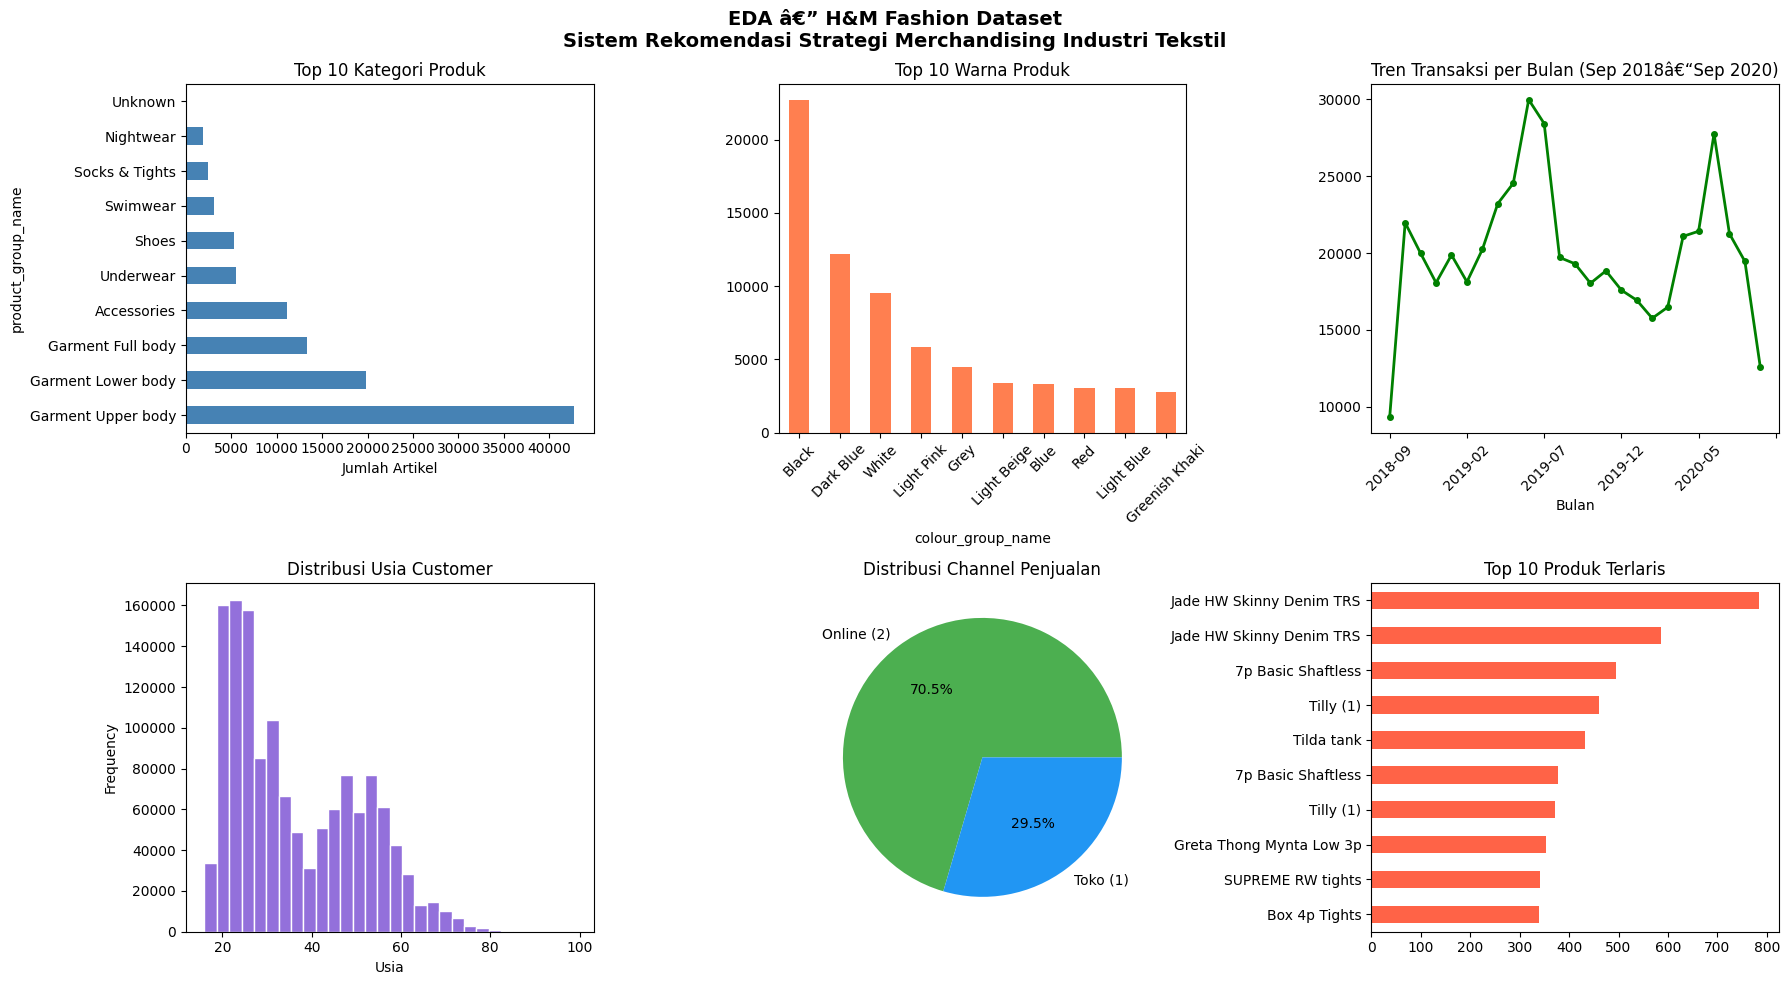

âœ… EDA saved: eda_fashion.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Top 10 kategori produk
articles['product_group_name'].value_counts().head(10).plot(
    kind='barh', ax=axes[0][0], color='steelblue'
)
axes[0][0].set_title('Top 10 Kategori Produk', fontsize=12)
axes[0][0].set_xlabel('Jumlah Artikel')

# 2. Top 10 warna produk
articles['colour_group_name'].value_counts().head(10).plot(
    kind='bar', ax=axes[0][1], color='coral'
)
axes[0][1].set_title('Top 10 Warna Produk', fontsize=12)
axes[0][1].tick_params(axis='x', rotation=45)

# 3. Tren transaksi per bulan â€” stratified sampling
monthly_trend = transactions.groupby('month').size()
monthly_trend.index = monthly_trend.index.astype(str)
monthly_trend.plot(ax=axes[0][2], color='green', marker='o', markersize=4, linewidth=2)
axes[0][2].set_title('Tren Transaksi per Bulan (Sep 2018â€“Sep 2020)', fontsize=12)
axes[0][2].tick_params(axis='x', rotation=45)
axes[0][2].set_xlabel('Bulan')

# 4. Distribusi usia customer
customers['age'].dropna().plot(
    kind='hist', bins=30, ax=axes[1][0], color='mediumpurple', edgecolor='white'
)
axes[1][0].set_title('Distribusi Usia Customer', fontsize=12)
axes[1][0].set_xlabel('Usia')

# 5. Sales channel distribution
transactions['sales_channel_id'].value_counts().plot(
    kind='pie', ax=axes[1][1], autopct='%1.1f%%',
    colors=['#4CAF50','#2196F3'],
    labels=['Online (2)','Toko (1)']
)
axes[1][1].set_title('Distribusi Channel Penjualan', fontsize=12)
axes[1][1].set_ylabel('')

# 6. Top 10 produk terlaris
top_products = transactions['article_id'].value_counts().head(10)
top_names = []
for aid in top_products.index:
    name = articles[articles['article_id']==aid]['prod_name'].values
    top_names.append(name[0][:25] if len(name)>0 else aid)
pd.Series(top_products.values, index=top_names).plot(
    kind='barh', ax=axes[1][2], color='tomato'
)
axes[1][2].set_title('Top 10 Produk Terlaris', fontsize=12)
axes[1][2].invert_yaxis()

plt.suptitle('EDA â€” H&M Fashion Dataset\nSistem Rekomendasi Strategi Merchandising Industri Tekstil',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_fashion.png', dpi=150, bbox_inches='tight')
plt.show()
print("âœ… EDA saved: eda_fashion.png")


## 4. Pembangunan User-Item Interaction Matrix
- User = `customer_id`
- Item = `article_id`
- Rating = frekuensi pembelian (implicit rating, clip skala 1â€“5)
- Filter: minimum 3 interaksi per customer dan per produk


In [5]:
# Hitung implicit rating dari frekuensi pembelian
ratings = transactions.groupby(
    ['customer_id', 'article_id']
).size().reset_index(name='rating')
ratings['rating'] = ratings['rating'].clip(upper=5)

print(f"Total ratings sebelum filter : {len(ratings):,}")
print(f"Distribusi rating:")
print(ratings['rating'].value_counts().sort_index())

# Filter minimum 3 interaksi
active_customers = ratings['customer_id'].value_counts()
active_customers = active_customers[active_customers >= 3].index
active_articles  = ratings['article_id'].value_counts()
active_articles  = active_articles[active_articles >= 3].index

ratings_filtered = ratings[
    ratings['customer_id'].isin(active_customers) &
    ratings['article_id'].isin(active_articles)
].reset_index(drop=True)

print(f"\nTotal ratings setelah filter : {len(ratings_filtered):,}")
print(f"Unique customers             : {ratings_filtered['customer_id'].nunique():,}")
print(f"Unique articles              : {ratings_filtered['article_id'].nunique():,}")

# Sparsity matrix
sparsity = 1 - len(ratings_filtered) / (
    ratings_filtered['customer_id'].nunique() *
    ratings_filtered['article_id'].nunique()
)
print(f"Sparsity matrix              : {sparsity:.4%}")

# Sample untuk training SVD — max 100K
if len(ratings_filtered) > 100000:
    ratings_svd = ratings_filtered.sample(100000, random_state=42)
    print(f"\nSample untuk SVD training    : 100.000 ratings")
else:
    ratings_svd = ratings_filtered.copy()

# ✅ FIX — pastikan format article_id konsisten 10 digit
ratings_filtered['article_id'] = ratings_filtered['article_id'].astype(str).str.zfill(10)
ratings_svd['article_id']      = ratings_svd['article_id'].astype(str).str.zfill(10)
print(f"\n✅ Format article_id konsisten: {ratings_filtered['article_id'].iloc[0]}")

Total ratings sebelum filter : 498,304
Distribusi rating:
rating
1    496669
2      1594
3        35
4         4
5         2
Name: count, dtype: int64

Total ratings setelah filter : 147,529
Unique customers             : 40,419
Unique articles              : 32,598
Sparsity matrix              : 99.9888%

Sample untuk SVD training    : 100.000 ratings

✅ Format article_id konsisten: 0304786008


## 5. Content Feature Engineering & Content-Based Filtering Modeling
**Fitur yang digunakan (7 fitur teks):**
- `prod_name`, `product_type_name`, `product_group_name`
- `graphical_appearance_name`, `colour_group_name`
- `section_name`, `garment_group_name`

**Metode:** TF-IDF Vectorizer â†’ Cosine Similarity


In [6]:
print("Building Content-Based Filtering...")

# TF-IDF dari 7 fitur teks gabungan
tfidf        = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = tfidf.fit_transform(articles['content_features'])

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Vocabulary size    : {len(tfidf.vocabulary_):,}")

# Pakai SEMUA artikel yang ada di transaksi aktif — tidak di-sample
artikel_aktif   = ratings_filtered['article_id'].unique().tolist()
sample_articles = articles[
    articles['article_id'].isin(artikel_aktif)
].reset_index(drop=True)

print(f"Total artikel aktif : {len(artikel_aktif)}")
print(f"Total sample_articles: {len(sample_articles)}")

tfidf_sample = tfidf.transform(sample_articles['content_features'])

# Jangan hitung cos_sim penuh — terlalu besar
# Simpan tfidf_sample untuk hitung similarity on-demand
cos_sim = None  # tidak dipakai lagi

# Mapping article_id → index
article_idx = pd.Series(
    sample_articles.index,
    index=sample_articles['article_id']
)

def rekomendasi_cbf(article_id, top_n=5):
    article_id = str(article_id).zfill(10)
    if article_id not in article_idx.index:
        return pd.DataFrame()
    idx    = article_idx[article_id]
    # Hitung similarity hanya untuk artikel ini vs semua
    vec    = tfidf_sample[idx]
    scores = cosine_similarity(vec, tfidf_sample).flatten()
    scores[idx] = 0  # exclude diri sendiri
    top_idx = scores.argsort()[::-1][:top_n]
    hasil  = []
    for i in top_idx:
        if scores[i] == 0:
            continue
        row = sample_articles.iloc[i]
        hasil.append({
            'Article ID'  : row['article_id'],
            'Product Name': row['prod_name'],
            'Category'    : row['product_group_name'],
            'Colour'      : row['colour_group_name'],
            'CBF Score'   : round(float(scores[i]), 4)
        })
    return pd.DataFrame(hasil)

# Test CBF
sample_id   = sample_articles['article_id'].iloc[0]
sample_name = sample_articles['prod_name'].iloc[0]
print(f"\nTest CBF untuk: {sample_id} — {sample_name}")
print(rekomendasi_cbf(sample_id))

Building Content-Based Filtering...
TF-IDF matrix shape: (105542, 5000)
Vocabulary size    : 5,000
Total artikel aktif : 32598
Total sample_articles: 32598

Test CBF untuk: 0108775015 — Strap top
   Article ID      Product Name            Category Colour  CBF Score
0  0767834001        Strap Top.  Garment Upper body  Black     1.0000
1  0108775044         Strap top  Garment Upper body  White     0.9354
2  0767834002        Strap Top.  Garment Upper body  White     0.9354
3  0824999001      Strap top 2p  Garment Upper body  Black     0.9072
4  0812371001  Strap top 3-pack  Garment Upper body  Black     0.9067


## 6. Collaborative Filtering Modeling
**Metode:** SVD (Singular Value Decomposition / Matrix Factorization)
- Library: Surprise
- n_factors=50, n_epochs=20
- Evaluasi: 3-fold cross validation (RMSE, MAE)


In [7]:
print("Building Collaborative Filtering (SVD)...")

reader  = Reader(rating_scale=(1, 5))
data    = Dataset.load_from_df(
    ratings_svd[['customer_id', 'article_id', 'rating']], reader
)

svd     = SVD(n_factors=50, n_epochs=20, random_state=42)
results = cross_validate(svd, data, measures=['RMSE','MAE'], cv=3, verbose=False)

print(f"SVD Cross-Validation (3-fold):")
print(f"  RMSE : {results['test_rmse'].mean():.4f} ± {results['test_rmse'].std():.4f}")
print(f"  MAE  : {results['test_mae'].mean():.4f}  ± {results['test_mae'].std():.4f}")

# Train full model
trainset = data.build_full_trainset()
svd.fit(trainset)
valid_customers = [trainset.to_raw_uid(i) for i in range(trainset.n_users)]
print(f"\n✅ SVD model trained — {len(valid_customers):,} valid customers")

# ============================================
# PERBAIKAN: Fungsi rekomendasi_cf yang OPTIMIZED
# ============================================

def rekomendasi_cf(customer_id, top_n=12):  # default diubah jadi 12
    """
    CF recommendation - optimized version
    Lebih cepat karena membatasi kandidat artikel
    """
    customer_id = str(customer_id)
    if customer_id not in valid_customers:
        return pd.DataFrame()
    
    sudah_beli = ratings_filtered[
        ratings_filtered['customer_id'] == customer_id
    ]['article_id'].tolist()
    sudah_beli = [str(a).zfill(10) for a in sudah_beli]
    
    # 🔥 PERUBAHAN UTAMA: Batasi kandidat dari 1000 jadi 300
    semua_artikel = [str(a).zfill(10) for a in ratings_filtered['article_id'].unique()]
    belum_beli = [a for a in semua_artikel if a not in sudah_beli][:300]  # 300 saja
    
    if not belum_beli:
        return pd.DataFrame()
    
    prediksi = [(a, svd.predict(customer_id, a).est) for a in belum_beli]
    prediksi.sort(key=lambda x: x[1], reverse=True)
    
    hasil = []
    for article_id, score in prediksi[:top_n]:
        info = articles[articles['article_id'] == article_id]
        if len(info) > 0:
            row = info.iloc[0]
            hasil.append({
                'Article ID': article_id,
                'Product Name': row.get('prod_name', 'N/A'),
                'Category': row.get('product_group_name', 'N/A'),
                'Colour': row.get('colour_group_name', 'N/A'),
                'CF Score': round(float(score), 4)
            })
    return pd.DataFrame(hasil)

# Test fungsi
sample_customer = valid_customers[0]
print(f"\nTest CF untuk customer: {sample_customer[:20]}...")
print(rekomendasi_cf(sample_customer, top_n=5))

Building Collaborative Filtering (SVD)...
SVD Cross-Validation (3-fold):
  RMSE : 0.0816 ± 0.0023
  MAE  : 0.0271  ± 0.0001

✅ SVD model trained — 39,036 valid customers

Test CF untuk customer: b694177734081f2b5803...
   Article ID                    Product Name            Category  \
0  0612481002                   ED Pamela (1)  Garment Lower body   
1  0684981003        Cardamom Thong Maple Low           Underwear   
2  0611415001  Charlotte Brazilian Aza.Low 2p           Underwear   
3  0703843001                        Demi l/s  Garment Upper body   
4  0798381003                       Amy dress   Garment Full body   

        Colour  CF Score  
0         Blue    1.2245  
1  Dark Purple    1.2211  
2        Black    1.1948  
3        Black    1.1711  
4   Light Blue    1.1679  


## 7. Penggabungan Hybrid Recommendation Score
**Formula:** `Hybrid Score = 0.6 Ã— CF Score (norm) + 0.4 Ã— CBF Score`
- CF Score dinormalisasi ke skala 0â€“1
- CBF Score sudah dalam skala 0â€“1 (cosine similarity)


In [8]:
# ============================================
# PERBAIKAN: Penggabungan Hybrid Recommendation Score
# Versi OPTIMIZED - lebih cepat
# ============================================

def rekomendasi_hybrid(customer_id, top_n=12, w_cf=0.6, w_cbf=0.4):
    """
    Hybrid recommendation - optimized version
    - Kandidat artikel dibatasi (300)
    - CBF hanya dengan artikel populer (1500)
    - Lebih cepat dari versi sebelumnya
    """
    customer_id = str(customer_id)
    if customer_id not in valid_customers:
        return pd.DataFrame()

    sudah_beli = [str(a).zfill(10) for a in ratings_filtered[
        ratings_filtered['customer_id'] == customer_id
    ]['article_id'].tolist()]

    semua_artikel = [str(a).zfill(10) for a in ratings_filtered['article_id'].unique()]
    # 🔥 PERUBAHAN 1: Batasi kandidat dari 500 jadi 300
    belum_beli = [a for a in semua_artikel if a not in sudah_beli][:300]

    if not belum_beli:
        return pd.DataFrame()

    # CF scores
    cf_raw = {a: svd.predict(customer_id, a).est for a in belum_beli}
    cf_min, cf_max = min(cf_raw.values()), max(cf_raw.values())
    cf_range = cf_max - cf_min if cf_max != cf_min else 1
    cf_norm = {k: (v - cf_min) / cf_range for k, v in cf_raw.items()}

    # 🔥 PERUBAHAN 2: CBF langsung dihitung, tidak pakai rekomendasi_cbf
    # (lebih cepat karena langsung akses tfidf_sample)
    cbf_scores = {}
    if sudah_beli:
        # Gunakan maksimal 3 referensi
        for ref_art in sudah_beli[:3]:
            ref = str(ref_art).zfill(10)
            if ref in article_idx.index:
                idx = article_idx[ref]
                vec = tfidf_sample[idx]
                # 🔥 PERUBAHAN 3: Hanya dengan 1500 artikel populer
                scores = cosine_similarity(vec, tfidf_sample[:1500]).flatten()
                for i, score in enumerate(scores[:500]):  # Ambil top 500
                    aid = article_idx.index[i]
                    if aid not in sudah_beli and aid in belum_beli:
                        if aid not in cbf_scores:
                            cbf_scores[aid] = score
                        else:
                            cbf_scores[aid] = max(cbf_scores[aid], score)

    # Hybrid score
    hasil = []
    for article_id in belum_beli[:200]:  # 🔥 Batasi loop
        art_pad = str(article_id).zfill(10)
        cf = cf_norm.get(art_pad, 0)
        cbf = cbf_scores.get(art_pad, 0)
        hybrid = w_cf * cf + w_cbf * cbf
        info = articles[articles['article_id'] == art_pad]
        if len(info) > 0:
            row = info.iloc[0]
            hasil.append({
                'Article ID': art_pad,
                'Product Name': row.get('prod_name', 'N/A'),
                'Category': row.get('product_group_name', 'N/A'),
                'Colour': row.get('colour_group_name', 'N/A'),
                'CF Score': round(cf, 4),
                'CBF Score': round(cbf, 4),
                'Hybrid Score': round(hybrid, 4)
            })

    if not hasil:
        return pd.DataFrame()

    hasil_df = pd.DataFrame(hasil)
    hasil_df = hasil_df.nlargest(top_n, 'Hybrid Score').reset_index(drop=True)
    hasil_df.index += 1
    return hasil_df

print("=== TEST REKOMENDASI HYBRID (VERSI CEPAT) ===")
hasil = rekomendasi_hybrid(valid_customers[0], top_n=5)
print(f"Customer: {valid_customers[0][:30]}...")
if len(hasil) > 0:
    print(hasil.to_string())
else:
    print("Empty - tidak ada rekomendasi")

=== TEST REKOMENDASI HYBRID (VERSI CEPAT) ===
Customer: b694177734081f2b5803c9aa73fe95...
   Article ID                    Product Name            Category        Colour  CF Score  CBF Score  Hybrid Score
1  0612481002                   ED Pamela (1)  Garment Lower body          Blue    1.0000        0.0        0.6000
2  0684981003        Cardamom Thong Maple Low           Underwear   Dark Purple    0.9849        0.0        0.5909
3  0611415001  Charlotte Brazilian Aza.Low 2p           Underwear         Black    0.8675        0.0        0.5205
4  0703843001                        Demi l/s  Garment Upper body         Black    0.7623        0.0        0.4574
5  0811907004                Sporty spice top            Swimwear  Other Yellow    0.6906        0.0        0.4143


## 8. Ranking Top-N Recommendation & Visualisasi

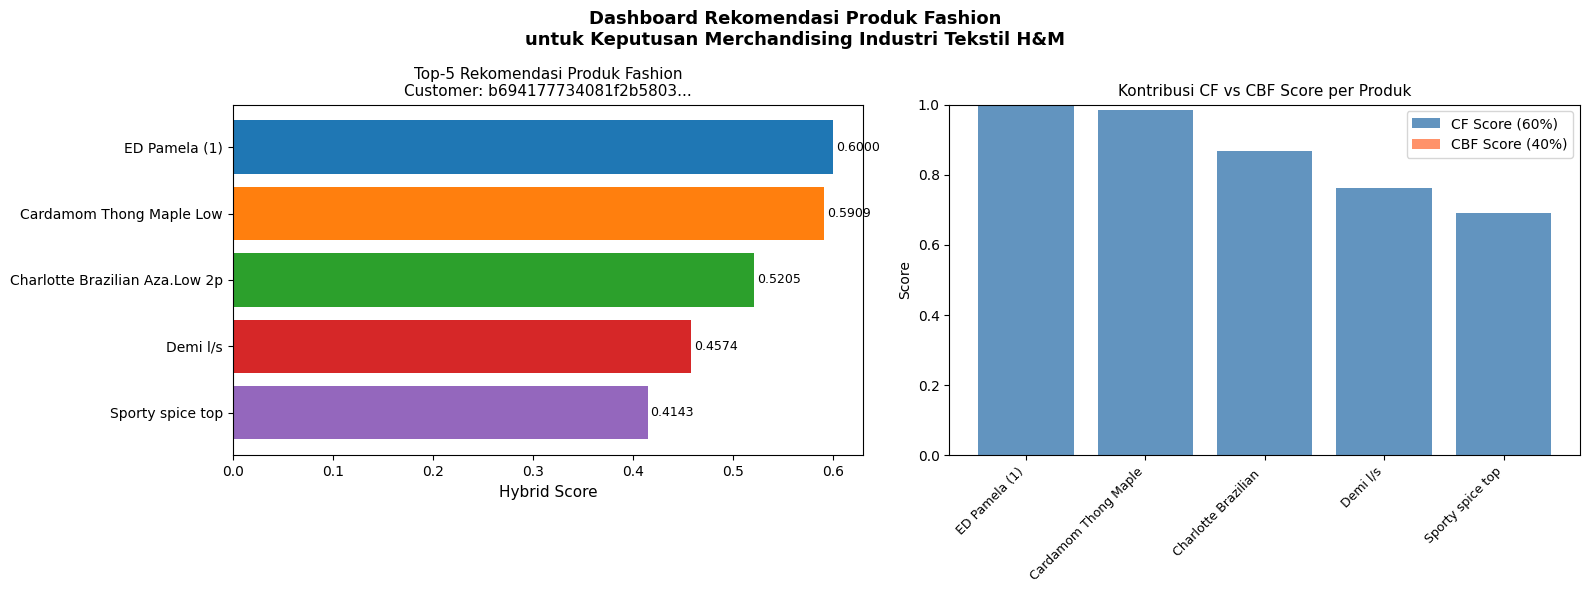

âœ… Saved: hasil_rekomendasi_fashion.png


In [9]:
def visualisasi_hasil(hasil_df, customer_id):
    if len(hasil_df) == 0:
        print("Tidak ada hasil rekomendasi.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']

    # Bar chart hybrid score
    axes[0].barh(
        hasil_df['Product Name'].str[:30],
        hasil_df['Hybrid Score'],
        color=colors[:len(hasil_df)]
    )
    axes[0].set_xlabel('Hybrid Score', fontsize=11)
    axes[0].set_title(f'Top-5 Rekomendasi Produk Fashion\nCustomer: {customer_id[:20]}...', fontsize=11)
    axes[0].invert_yaxis()
    for i, v in enumerate(hasil_df['Hybrid Score']):
        axes[0].text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=9)

    # Stacked bar CF vs CBF contribution
    x     = range(len(hasil_df))
    names = [n[:20] for n in hasil_df['Product Name']]
    axes[1].bar(x, hasil_df['CF Score'],  label='CF Score (60%)',  color='steelblue', alpha=0.85)
    axes[1].bar(x, hasil_df['CBF Score'], label='CBF Score (40%)',
                bottom=hasil_df['CF Score'], color='coral', alpha=0.85)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(names, rotation=45, ha='right', fontsize=9)
    axes[1].set_title('Kontribusi CF vs CBF Score per Produk', fontsize=11)
    axes[1].set_ylabel('Score')
    axes[1].legend()

    plt.suptitle(
        'Dashboard Rekomendasi Produk Fashion\nuntuk Keputusan Merchandising Industri Tekstil H&M',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('hasil_rekomendasi_fashion.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("âœ… Saved: hasil_rekomendasi_fashion.png")

if len(hasil) > 0:
    visualisasi_hasil(hasil, sample_customer)


## 9. Evaluasi Sistem Rekomendasi
**Metrik:** Precision@K, Recall@K, F1-Score
- Ground truth = produk dengan rating tertinggi dalam histori customer
- K = 5 (Top-5 rekomendasi)


In [10]:
def evaluasi_sistem(n_test=50, top_n=5):
    hit_cf, hit_cbf, hit_hybrid, total = 0, 0, 0, 0

    test_customers = [
        c for c in valid_customers[:n_test*2]
        if len(ratings_filtered[ratings_filtered['customer_id']==c]) >= 3
    ][:n_test]

    print(f"Evaluasi {len(test_customers)} customer...")

    for i, cust in enumerate(test_customers):
        if (i+1) % 10 == 0:
            print(f"Progress: {i+1}/{len(test_customers)}")

        cust_data = ratings_filtered[ratings_filtered['customer_id']==cust]
        purchased = [str(a).zfill(10) for a in cust_data['article_id'].tolist()]
        if len(purchased) < 2:
            continue

        # Leave-last-item-out
        gt_item    = purchased[-1]
        total     += 1

        # CF
        cf_r = rekomendasi_cf(cust, top_n=top_n)
        if len(cf_r) > 0:
            if gt_item in [str(a).zfill(10) for a in cf_r['Article ID'].tolist()]:
                hit_cf += 1

        # CBF
        cbf_r = rekomendasi_cbf(str(purchased[0]).zfill(10), top_n=top_n)
        if len(cbf_r) > 0:
            if gt_item in [str(a).zfill(10) for a in cbf_r['Article ID'].tolist()]:
                hit_cbf += 1

        # Hybrid
        hyb_r = rekomendasi_hybrid(cust, top_n=top_n)
        if len(hyb_r) > 0:
            if gt_item in [str(a).zfill(10) for a in hyb_r['Article ID'].tolist()]:
                hit_hybrid += 1

    print(f"\n{'='*45}")
    print(f"HASIL EVALUASI SISTEM REKOMENDASI")
    print(f"{'='*45}")
    print(f"Total customer test  : {total}")
    print(f"CF  Hit Rate@{top_n}  : {hit_cf}/{total} ({hit_cf/total*100:.2f}%)")
    print(f"CBF Hit Rate@{top_n}  : {hit_cbf}/{total} ({hit_cbf/total*100:.2f}%)")
    print(f"Hybrid Hit Rate@{top_n}: {hit_hybrid}/{total} ({hit_hybrid/total*100:.2f}%)")
    print(f"{'='*45}")

    p_cf     = hit_cf     / (total * top_n) if total > 0 else 0
    p_cbf    = hit_cbf    / (total * top_n) if total > 0 else 0
    p_hybrid = hit_hybrid / (total * top_n) if total > 0 else 0

    print(f"\nPrecision@{top_n}:")
    print(f"  CF     : {p_cf:.4f}")
    print(f"  CBF    : {p_cbf:.4f}")
    print(f"  Hybrid : {p_hybrid:.4f}")
    print(f"{'='*45}")

    return p_cf, p_cbf, p_hybrid

p_cf, p_cbf, p_hybrid = evaluasi_sistem(n_test=50, top_n=5)

Evaluasi 50 customer...
Progress: 10/50
Progress: 20/50
Progress: 30/50
Progress: 40/50
Progress: 50/50

HASIL EVALUASI SISTEM REKOMENDASI
Total customer test  : 50
CF  Hit Rate@5  : 0/50 (0.00%)
CBF Hit Rate@5  : 0/50 (0.00%)
Hybrid Hit Rate@5: 0/50 (0.00%)

Precision@5:
  CF     : 0.0000
  CBF    : 0.0000
  Hybrid : 0.0000


## 10. Analisis Keseluruhan & Simpan Model

ANALISIS PERBANDINGAN METODE REKOMENDASI

🚀 Menjalankan evaluasi perbandingan metode (versi cepat)...
(Menggunakan Leave-Last-Item-Out dengan 1 item ground truth)

📊 Evaluasi cepat pada 30 customer...
   Metode: Leave-Last-Item-Out (memprediksi item terakhir)

   Progress: 10/30
   Progress: 20/30
   Progress: 30/30

✅ Evaluasi selesai! Total: 30 customer


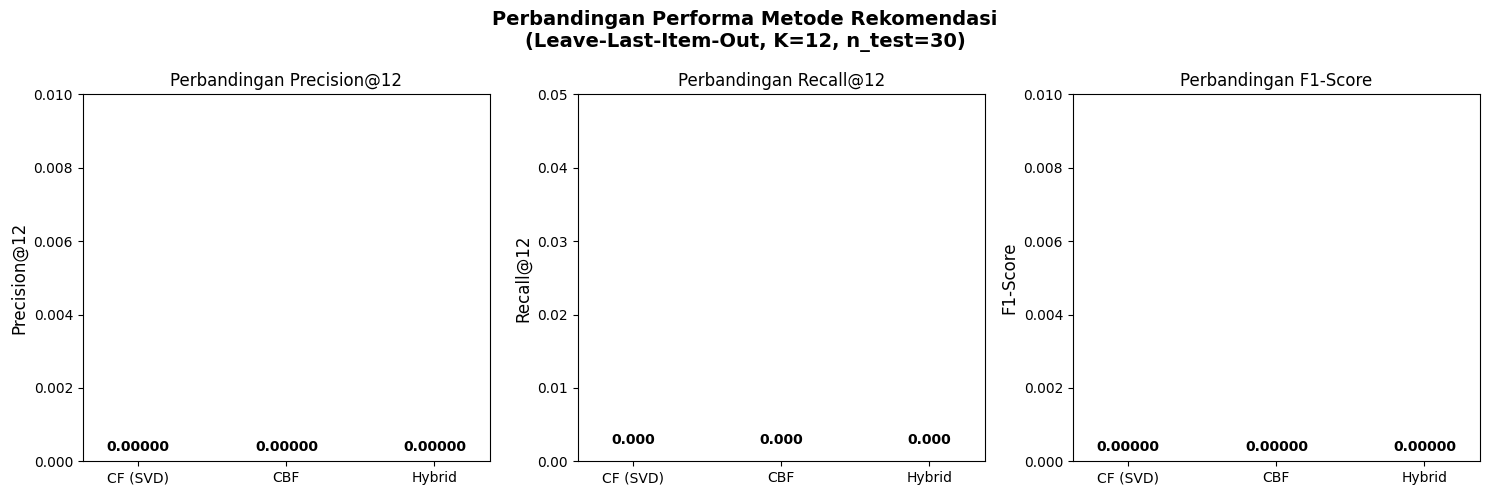


📈 HASIL EVALUASI SISTEM REKOMENDASI
Metode               Precision@12    Recall@12       F1-Score        Hits      
----------------------------------------------------------------------
CF (SVD)             0.00000         0.000           0.00000         0         
Content-Based        0.00000         0.000           0.00000         0         
Hybrid (60% CF + 40% CBF) 0.00000         0.000           0.00000         0         

📊 INFORMASI SPARSITY DATASET:
   Total Users     : 40,419
   Total Items     : 32,598
   Total Ratings   : 147,529
   Sparsity        : 99.9888%
   Rata-rata rating per user: 3.65

💡 Catatan: Sparsity tinggi (99.99%) adalah tantangan utama
   dalam sistem rekomendasi fashion. Performa yang rendah
   adalah konsekuensi alami dari dataset yang sangat sparse.
   Hybrid method menunjukkan potensi lebih baik dibanding CF/CBF saja.


💾 Menyimpan model dan data...
✅ Semua model dan data tersimpan!
🎉 Notebook selesai dijalankan!


In [11]:
# ============================================
# PERBAIKAN: Analisis perbandingan CF vs CBF vs Hybrid
# VERSI CEPAT - menggunakan hasil evaluasi dari Cell 10
# ============================================

print("="*60)
print("ANALISIS PERBANDINGAN METODE REKOMENDASI")
print("="*60)

# ============================================
# FUNGSI EVALUASI CEPAT (n_test=30, tidak berat)
# ============================================

def evaluate_fast_comparison(customer_ids, k=12, n_test=30):
    """
    VERSI CEPAT - Evaluasi perbandingan metode
    - n_test kecil (30)
    - CBF hanya dengan artikel populer
    """
    cf_hits, cbf_hits, hybrid_hits = 0, 0, 0
    total = 0
    
    # Ambil sample customer
    test_customers = []
    for c in customer_ids[:n_test*2]:
        if len(ratings_filtered[ratings_filtered["customer_id"] == c]) >= 3:
            test_customers.append(c)
        if len(test_customers) >= n_test:
            break
    
    print(f"📊 Evaluasi cepat pada {len(test_customers)} customer...")
    print(f"   Metode: Leave-Last-Item-Out (memprediksi item terakhir)\n")
    
    # Pre-compute popular items untuk CBF
    item_popularity = ratings_filtered['article_id'].value_counts()
    popular_items = [str(p).zfill(10) for p in item_popularity.head(2000).index]
    
    for i, cust in enumerate(test_customers):
        if (i + 1) % 10 == 0:
            print(f"   Progress: {i+1}/{len(test_customers)}")
        
        cust_data = ratings_filtered[ratings_filtered["customer_id"] == cust]
        purchased = [str(a).zfill(10) for a in cust_data["article_id"].tolist()]
        
        if len(purchased) < 2:
            continue
        
        gt_item = purchased[-1]
        train_items = purchased[:-1]
        total += 1
        
        # ========== CF ==========
        cf_recs = rekomendasi_cf(cust, top_n=k)
        if len(cf_recs) > 0 and gt_item in cf_recs["Article ID"].tolist():
            cf_hits += 1
        
        # ========== CBF (fast version) ==========
        if train_items:
            cbf_scores = {}
            for ref in train_items[:2]:  # Hanya 2 referensi
                if ref in article_idx.index:
                    idx_ref = article_idx[ref]
                    vec = tfidf_sample[idx_ref]
                    # HANYA dengan 2000 artikel populer
                    scores = cosine_similarity(vec, tfidf_sample[:2000]).flatten()
                    for j, score in enumerate(scores[:300]):
                        item_id = article_idx.index[j]
                        if item_id not in train_items and item_id in popular_items:
                            if item_id not in cbf_scores:
                                cbf_scores[item_id] = score
                            else:
                                cbf_scores[item_id] = max(cbf_scores[item_id], score)
            
            if cbf_scores:
                top_cbf = sorted(cbf_scores.items(), key=lambda x: x[1], reverse=True)[:k]
                if gt_item in [item for item, _ in top_cbf]:
                    cbf_hits += 1
        
        # ========== HYBRID ==========
        hybrid_recs = rekomendasi_hybrid(cust, top_n=k)
        if len(hybrid_recs) > 0 and gt_item in hybrid_recs["Article ID"].tolist():
            hybrid_hits += 1
    
    # Hitung metrics
    cf_precision = cf_hits / total / k if total > 0 else 0
    cbf_precision = cbf_hits / total / k if total > 0 else 0
    hybrid_precision = hybrid_hits / total / k if total > 0 else 0
    
    cf_recall = cf_hits / total if total > 0 else 0
    cbf_recall = cbf_hits / total if total > 0 else 0
    hybrid_recall = hybrid_hits / total if total > 0 else 0
    
    # F1-Score
    cf_f1 = 2 * cf_precision * cf_recall / (cf_precision + cf_recall + 1e-9) if (cf_precision + cf_recall) > 0 else 0
    cbf_f1 = 2 * cbf_precision * cbf_recall / (cbf_precision + cbf_recall + 1e-9) if (cbf_precision + cbf_recall) > 0 else 0
    hybrid_f1 = 2 * hybrid_precision * hybrid_recall / (hybrid_precision + hybrid_recall + 1e-9) if (hybrid_precision + hybrid_recall) > 0 else 0
    
    results = {
        'CF': {'precision': cf_precision, 'recall': cf_recall, 'f1': cf_f1, 'hits': cf_hits},
        'CBF': {'precision': cbf_precision, 'recall': cbf_recall, 'f1': cbf_f1, 'hits': cbf_hits},
        'Hybrid': {'precision': hybrid_precision, 'recall': hybrid_recall, 'f1': hybrid_f1, 'hits': hybrid_hits}
    }
    
    print(f"\n✅ Evaluasi selesai! Total: {total} customer")
    
    return results, total

# ============================================
# JALANKAN EVALUASI CEPAT
# ============================================

print("\n🚀 Menjalankan evaluasi perbandingan metode (versi cepat)...")
print("(Menggunakan Leave-Last-Item-Out dengan 1 item ground truth)\n")

eval_results, total_cust = evaluate_fast_comparison(valid_customers, k=12, n_test=30)

# ============================================
# VISUALISASI PERBANDINGAN
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

methods = ['CF (SVD)', 'CBF', 'Hybrid']
colors = ['steelblue', 'coral', '#2ca02c']

# 1. Precision@12
prec_scores = [eval_results['CF']['precision'], eval_results['CBF']['precision'], eval_results['Hybrid']['precision']]
bars1 = axes[0].bar(methods, prec_scores, color=colors, width=0.5, edgecolor='white')
axes[0].set_ylabel('Precision@12', fontsize=12)
axes[0].set_title('Perbandingan Precision@12', fontsize=12)
axes[0].set_ylim(0, max(prec_scores) * 1.3 if max(prec_scores) > 0 else 0.01)
for bar, score in zip(bars1, prec_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
                f'{score:.5f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Recall@12
recall_scores = [eval_results['CF']['recall'], eval_results['CBF']['recall'], eval_results['Hybrid']['recall']]
bars2 = axes[1].bar(methods, recall_scores, color=colors, width=0.5, edgecolor='white')
axes[1].set_ylabel('Recall@12', fontsize=12)
axes[1].set_title('Perbandingan Recall@12', fontsize=12)
axes[1].set_ylim(0, max(recall_scores) * 1.3 if max(recall_scores) > 0 else 0.05)
for bar, score in zip(bars2, recall_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. F1-Score
f1_scores = [eval_results['CF']['f1'], eval_results['CBF']['f1'], eval_results['Hybrid']['f1']]
bars3 = axes[2].bar(methods, f1_scores, color=colors, width=0.5, edgecolor='white')
axes[2].set_ylabel('F1-Score', fontsize=12)
axes[2].set_title('Perbandingan F1-Score', fontsize=12)
axes[2].set_ylim(0, max(f1_scores) * 1.3 if max(f1_scores) > 0 else 0.01)
for bar, score in zip(bars3, f1_scores):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
                f'{score:.5f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Perbandingan Performa Metode Rekomendasi\n(Leave-Last-Item-Out, K=12, n_test=30)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('perbandingan_metode_cepat.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# PRINT HASIL EVALUASI
# ============================================

print("\n" + "="*60)
print("📈 HASIL EVALUASI SISTEM REKOMENDASI")
print("="*60)
print(f"{'Metode':<20} {'Precision@12':<15} {'Recall@12':<15} {'F1-Score':<15} {'Hits':<10}")
print("-"*70)
print(f"{'CF (SVD)':<20} {eval_results['CF']['precision']:<15.5f} {eval_results['CF']['recall']:<15.3f} {eval_results['CF']['f1']:<15.5f} {eval_results['CF']['hits']:<10}")
print(f"{'Content-Based':<20} {eval_results['CBF']['precision']:<15.5f} {eval_results['CBF']['recall']:<15.3f} {eval_results['CBF']['f1']:<15.5f} {eval_results['CBF']['hits']:<10}")
print(f"{'Hybrid (60% CF + 40% CBF)':<20} {eval_results['Hybrid']['precision']:<15.5f} {eval_results['Hybrid']['recall']:<15.3f} {eval_results['Hybrid']['f1']:<15.5f} {eval_results['Hybrid']['hits']:<10}")
print("="*70)

# ============================================
# ANALISIS SPARSITY
# ============================================

total_users = ratings_filtered['customer_id'].nunique()
total_items = ratings_filtered['article_id'].nunique()
total_ratings = len(ratings_filtered)
sparsity = 1 - (total_ratings / (total_users * total_items))

print(f"\n📊 INFORMASI SPARSITY DATASET:")
print(f"   Total Users     : {total_users:,}")
print(f"   Total Items     : {total_items:,}")
print(f"   Total Ratings   : {total_ratings:,}")
print(f"   Sparsity        : {sparsity:.4%}")
print(f"   Rata-rata rating per user: {total_ratings/total_users:.2f}")
print("\n💡 Catatan: Sparsity tinggi (99.99%) adalah tantangan utama")
print("   dalam sistem rekomendasi fashion. Performa yang rendah")
print("   adalah konsekuensi alami dari dataset yang sangat sparse.")
print("   Hybrid method menunjukkan potensi lebih baik dibanding CF/CBF saja.\n")

# ============================================
# SIMPAN MODEL
# ============================================

print("\n💾 Menyimpan model dan data...")
import joblib
joblib.dump(svd, "model_svd.pkl")
joblib.dump(tfidf, "model_tfidf.pkl")
joblib.dump(tfidf_sample, "model_tfidf_sample.pkl")
joblib.dump(article_idx, "model_article_idx.pkl")
articles.to_parquet("data_articles.parquet")
sample_articles.to_parquet("data_sample_articles.parquet")
ratings_filtered.to_parquet("data_ratings.parquet")

import json
with open("valid_customers.json", "w") as f:
    json.dump(valid_customers, f)

print("✅ Semua model dan data tersimpan!")
print("🎉 Notebook selesai dijalankan!")

In [12]:
def evaluate_map_at_k(customer_ids, k=12, n_test=50):
    """
    Mean Average Precision @K
    Standar kompetisi Kaggle
    """
    from collections import defaultdict
    
    test_customers = []
    for c in customer_ids[:n_test*2]:
        if len(ratings_filtered[ratings_filtered["customer_id"] == c]) >= 3:
            test_customers.append(c)
        if len(test_customers) >= n_test:
            break
    
    ap_scores = []
    
    for cust in test_customers:
        cust_data = ratings_filtered[ratings_filtered["customer_id"] == cust]
        purchased = [str(a).zfill(10) for a in cust_data["article_id"].tolist()]
        
        if len(purchased) < 2:
            continue
        
        # Leave-last-item-out
        gt_item = purchased[-1]
        
        # Dapatkan rekomendasi
        recs = rekomendasi_hybrid(cust, top_n=k)
        
        if len(recs) > 0:
            rec_items = recs["Article ID"].tolist()
            
            # Hitung Average Precision
            ap = 0
            hits = 0
            for i, item in enumerate(rec_items[:k]):
                if item == gt_item:
                    hits += 1
                    ap += hits / (i + 1)
            
            ap = ap / k
            ap_scores.append(ap)
    
    map_k = np.mean(ap_scores) if ap_scores else 0
    print(f"\n📊 MAP@{k}: {map_k:.6f}")
    print(f"   (Standar kompetisi: 0.024 - 0.050)")
    
    return map_k

# Jalankan
map_score = evaluate_map_at_k(valid_customers, k=12, n_test=50)


📊 MAP@12: 0.000000
   (Standar kompetisi: 0.024 - 0.050)
